#### Decision tree classification with 'features_classified.pkl'
This notebook tests the effectiveness of predicting with 'features_classified.pkl' and Decision tree classifier
- Split and scale dataset
- Train decision tree classifier using features.pkl dataset to determine the hyperparameters that maximize profit function
 -Make predictions to analyse the importance of each feature
- Determine the hyperparameters that maximize profit function using the most significant features
- Save the trained model
- Create a report showing dataset used, hyperparameters tested and results

In [6]:
import yaml 
import sys
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/data/')
from make_dataset import *
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/models/')
from train_model import *
import pandas as pd
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.inspection import permutation_importance
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import shap
from datetime import datetime

In [7]:
interim_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/interim/'
processed_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/processed/'

with open('C:/Users/inesm/projectos/tennis-predictor/conf/conf.yaml', 'r') as config_file:
    conf = yaml.safe_load(config_file)

In [8]:
model = 'decision-tree'
today_date = datetime.now().strftime('%Y-%m-%d-%H%M') 

# Save configs tested and results in an HTML report
report_path = '../features-classified-{}-training-report-{}.html'.format(model, today_date)

In [9]:
dataset = load_data(processed_filepath, file_name='features_classified.pkl')
aux_dataset = load_data(processed_filepath, file_name='features.pkl')

dataset.describe()

,match_id,Surface_Carpet,Surface_Clay,Surface_Grass,Surface_Hard,H2H,Y_B365,winner_is_p1,RankP1,RankP2,Rank_dif,OddP1,OddP2,Odd_dif
count,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000
mean,19260.113668,0.032340,0.316139,0.112278,0.539243,0.326208,0.678425,0.703166,11.839104,11.923367,6.948479,6.722069,6.764695,6.806857
std,9990.255185,0.176904,0.464975,0.315713,0.498465,1.267710,0.111162,0.456870,7.302810,7.236406,4.303529,4.308726,4.409008,4.295666
min,1371.000000,0.000000,0.000000,0.000000,0.000000,-10.000000,0.147059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10697.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589005,0.000000,6.000000,6.000000,3.000000,3.000000,3.000000,3.000000
50%,19393.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.662651,1.000000,12.000000,12.000000,7.000000,7.000000,7.000000,7.000000
75%,27902.500000,0.000000,1.000000,0.000000,1.000000,1.000000,0.766284,1.000000,18.000000,18.000000,11.000000,10.000000,11.000000,11.000000
max,36362.000000,1.000000,1.000000,1.000000,1.000000,16.000000,0.906618,1.000000,24.000000,24.000000,14.000000,14.000000,14.000000,14.000000


In [10]:
y = dataset['winner_is_p1']

In [11]:
all_features = dataset.drop('winner_is_p1', axis = 1)

In [12]:
def split_data(X_id, y):
    # Define size of validation data
    train_size = float(conf["training"]["train_size"])
    test_size = conf["training"]["test_size"]
    cv = conf["training"]["cv"]

    if cv != None: 
        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X_id, y, test_size=test_size, random_state=42)
        logger.info(f"Splitting data randomly into a training ({train_size * 100}%) and a testing ({test_size * 100}%) datasets.")
        return X_train, X_test, y_train, y_test
    else:
        # define validation size
        temp_size = 1 - train_size
        test_val_ratio = test_size / temp_size
        
        # Split data into training, validation and testing sets
        X_train, X_temp, y_train, y_temp = train_test_split(X_id, y, test_size=temp_size, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_val_ratio, random_state=42)
        logger.info(f"Splitting data randomly into a training ({train_size * 100}%), a validation ({round(1 - train_size - test_size, 2) * 100}%) and a testing ({test_size * 100}%) datasets.")
        return X_train, X_val, X_test, y_train, y_val, y_test


In [15]:
X_train_id, X_test_id, y_train, y_test = split_data(all_features, y)

# add oddP1 and OddP2 to dataset for custom_profit calculations
X_train_aux = pd.merge(X_train_id, aux_dataset, on='match_id')  
X_test_aux = pd.merge(X_test_id, aux_dataset, on='match_id')  

X_train = X_train_id.drop(['match_id'], axis = 1)
X_test = X_test_id.drop(['match_id'], axis = 1)

In [16]:
# Create a decision tree classifier
classifier = DecisionTreeClassifier(
    class_weight=conf['training']['class_weights'], # assign a higher weight to the least frequent class (0: P2 wins) to make the model pay more attention to it during training
    random_state=42)

In [17]:
def custom_profit(y, y_pred, Odd_P1, Odd_P2):
    ''' Takes two np.arrays with real and predicted values
    and it's odds and returns the profit. '''

    # Define costs and benefits
    Benefit_TP = Odd_P1 - 1  # Benefit for true positives
    Benefit_TN = Odd_P2 - 1  # Benefit for true negatives
    Cost_FP = -1  # Cost for false positives
    Cost_FN = -1  # Cost for false negatives

    # Calculate TP, TN, FP, FN based on true labels and predictions
    TP = (y == 1) & (y_pred == 1)
    TN = (y == 0) & (y_pred == 0)
    FP = (y == 0) & (y_pred == 1)
    FN = (y == 1) & (y_pred == 0)
    
    profit = Benefit_TP * (TP == True) + Benefit_TN * (TN == True) + Cost_FP * (FP == True) + Cost_FN * (FN == True)
    profitability = 100 * (((profit.sum() + len(y)) / len(y)) - 1)
        
    print('Financial results betting 1€ on each bet')
    print('Invested amount: {:.2f}€'.format(len(y)))
    print('Profit: {:.2f}€'.format(profit.sum()))
    print('profitability: {:.2f}%'.format(profitability))
    return profit.sum()

def training(X, y, OddP1, OddP2):

    # Grid search for hyperparameter tuning
    param_grid = conf[model]['param_grid']

    # Define the objective function
    custom_scorer = lambda estimator, X, y: custom_profit(y, 
                                                         estimator.predict(X), 
                                                         OddP1, 
                                                         OddP2)

    grid_search = GridSearchCV(classifier, param_grid, cv=conf['training']['cv'], scoring=custom_scorer)

    grid_search.fit(X, y)
    
    # Print the best hyperparameters
    print('Best Hyperparameters:', grid_search.best_params_)

    return classifier, grid_search.best_params_

classifier, best_params = training(X_train, y_train, X_train_aux['OddP1_y'], X_train_aux['OddP2_y'])

Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 565.56€
profitability: 9.70%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 511.19€
profitability: 8.77%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 586.25€
profitability: 10.06%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 586.39€
profitability: 10.06%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 427.20€
profitability: 7.33%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 528.07€
profitability: 9.06%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 629.77€
profitability: 10.81%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 786.93€
profitability: 13.50%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 643.07€
profitability: 11.04%
Financial results betting 1€ on each bet
Invested amount: 5

In [18]:
# Additional parameters (you may have other parameters like class_weight)
additional_params = {
    'class_weight': conf['training']['class_weights'],
    'random_state': 42
}

# Combine best_params and additional_params to create the final parameters
final_params = {**best_params, **additional_params}

# Create a decision tree classifier with the best parameters
classifier = DecisionTreeClassifier(**final_params)

# Train the model on the training data
classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print the results
print('Accuracy:', accuracy)
print('Classification Report:\n', report)

profit = custom_profit(y_test, classifier.predict(X_test), X_test_aux['OddP1_y'], X_test_aux['OddP2_y'])

Accuracy: 0.55775169857937
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.81      0.52       973
           1       0.84      0.45      0.59      2265

    accuracy                           0.56      3238
   macro avg       0.62      0.63      0.56      3238
weighted avg       0.71      0.56      0.57      3238

Financial results betting 1€ on each bet
Invested amount: 3238.00€
Profit: 45.28€
profitability: 1.40%


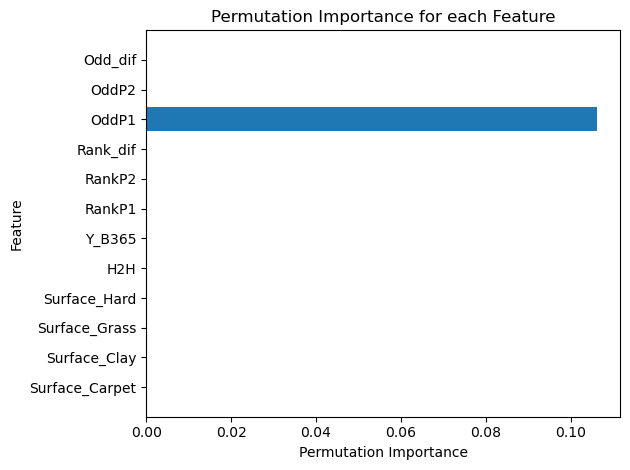

In [19]:
# Assuming trained_model is your KerasRegressor
result = permutation_importance(classifier, X_test, y_test, n_repeats=10, random_state=42)

# Get feature importances
importances = result.importances_mean

feature_names = X_train.columns

# Plot the feature importances
plt.barh(range(len(feature_names)), importances, tick_label=feature_names)  # Use barh for horizontal bars
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Permutation Importance for each Feature')
plt.tight_layout()
plt.savefig(f"../figures/{model}-permutation-importances-{today_date}.png")
plt.show()
plt.close()  # Close the plot to avoid saving additional figures


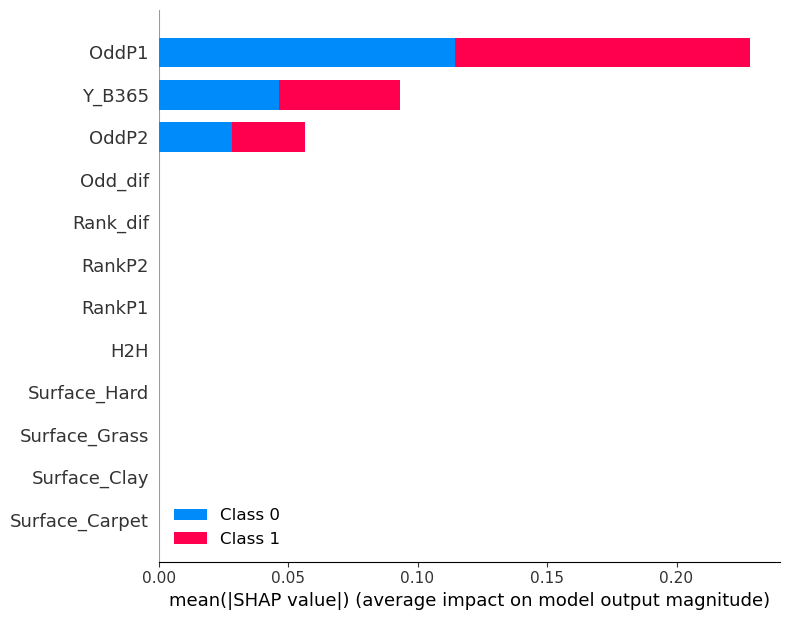

In [20]:
# Create a SHAP explainer object
explainer = shap.TreeExplainer(classifier)

# Calculate SHAP values for a set of instances (e.g., X_test)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type='bar')

# Force plot for a specific instance (e.g., the first instance)
shap.force_plot(explainer.expected_value[1], shap_values[1][0, :], X_test.iloc[0, :])

# Save the force plot as PNG
plt.savefig(f"../figures/{model}-shap-analysis.png")
plt.close()  # Close the plot to avoid saving additional figures


Features:
- OddP1

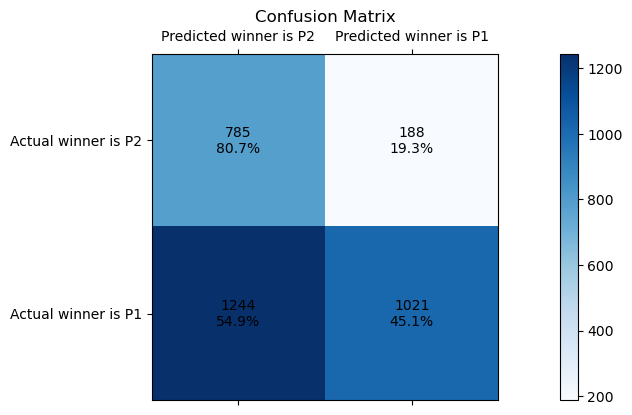

In [21]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate percentages for the confusion matrix
percentage_matrix = (conf_matrix.T / conf_matrix.sum(axis=1)).T * 100  # Calculate percentages for each row

# Create a figure and axes
fig, ax = plt.subplots(1, 1, figsize=(16, 4.5))

# Plot the confusion matrix
cax = ax.matshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Percentages')
plt.colorbar(cax)

# Annotate the cells with the percentage values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, '{}\n{:.1f}%'.format(conf_matrix[i, j], percentage_matrix[i, j]), ha='center', va='center')

# Add labels for clarity
plt.xticks(np.arange(conf_matrix.shape[1]), labels=['Predicted winner is P2', 'Predicted winner is P1'])
plt.yticks(np.arange(conf_matrix.shape[0]), labels=['Actual winner is P2', 'Actual winner is P1'])

plt.title('Confusion Matrix')
plt.savefig(f"../figures/{model}-confusion-matrix.png")
plt.show()
plt.close()

Training with the most important features according to features correlation (correlation-matrix), permutation importance and shap analysis

In [25]:
features_names = ['OddP1']
features_names.extend(['match_id'])

final_X_train_id = X_train_id[features_names]
final_X_train = final_X_train_id.drop(['match_id'], axis = 1)

final_X_test_id = X_test_id[features_names]
final_X_test = final_X_test_id.drop(['match_id'], axis = 1)

In [26]:
classifier, best_params = training(final_X_train, y_train, X_train_aux['OddP1_y'], X_train_aux['OddP2_y'])

Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 1341.40€
profitability: 23.02%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 1513.65€
profitability: 25.97%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 1501.07€
profitability: 25.76%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 1444.26€
profitability: 24.79%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 1450.25€
profitability: 24.89%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 1341.40€
profitability: 23.02%
Financial results betting 1€ on each bet
Invested amount: 5828.00€
Profit: 1513.65€
profitability: 25.97%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 1501.07€
profitability: 25.76%
Financial results betting 1€ on each bet
Invested amount: 5827.00€
Profit: 1444.26€
profitability: 24.79%
Financial results betting 1€ on each bet
Inves

In [27]:
# Additional parameters (you may have other parameters like class_weight)
additional_params = {
    'class_weight': conf['training']['class_weights'],
    'random_state': 42
}

# Combine best_params and additional_params to create the final parameters
final_params = {**best_params, **additional_params}

# Create a decision tree classifier with the best parameters
classifier = RandomForestClassifier(**final_params)

# Train the model on the training data
classifier.fit(final_X_train, y_train)

# Make predictions on the test data
y_pred = classifier.predict(final_X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print the results
print('Accuracy:', accuracy)
print('Classification Report:\n', report)

profit = custom_profit(y_test, classifier.predict(final_X_test), X_test_aux['OddP1_y'], X_test_aux['OddP2_y'])

Accuracy: 0.55775169857937
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.81      0.52       973
           1       0.84      0.45      0.59      2265

    accuracy                           0.56      3238
   macro avg       0.62      0.63      0.56      3238
weighted avg       0.71      0.56      0.57      3238

Financial results betting 1€ on each bet
Invested amount: 3238.00€
Profit: 45.28€
profitability: 1.40%


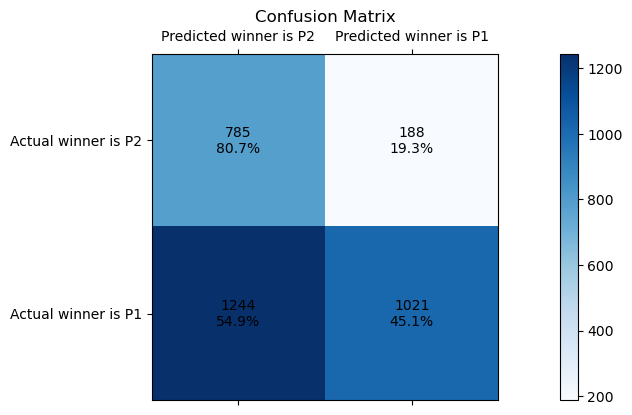

In [28]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate percentages for the confusion matrix
percentage_matrix = (conf_matrix.T / conf_matrix.sum(axis=1)).T * 100  # Calculate percentages for each row

# Create a figure and axes
fig, ax = plt.subplots(1, 1, figsize=(16, 4.5))

# Plot the confusion matrix
cax = ax.matshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Percentages')
plt.colorbar(cax)

# Annotate the cells with the percentage values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, '{}\n{:.1f}%'.format(conf_matrix[i, j], percentage_matrix[i, j]), ha='center', va='center')

# Add labels for clarity
plt.xticks(np.arange(conf_matrix.shape[1]), labels=['Predicted winner is P2', 'Predicted winner is P1'])
plt.yticks(np.arange(conf_matrix.shape[0]), labels=['Actual winner is P2', 'Actual winner is P1'])

plt.title('Confusion Matrix')
plt.savefig(f"../figures/{model}-confusion-matrix.png")
plt.show()
plt.close()

In [30]:
profit

45.282999999999994

In [31]:
# Add custom CSS styling for spacing between cells
custom_style = '<style>td, th { padding: 8px; }</style>'

# convert df to html table  
html_df = dataset.describe().to_html(float_format='%.2f', classes='table', border=0, justify='center')
html_dataset = f'{custom_style}{html_df}'

# convert df to html table  
html_df = X_train.describe().to_html(float_format='%.2f', classes='table', border=0, justify='center')
html_X_train = f'{custom_style}{html_df}'

# create table for param_grid
html_table = '<table border="1">\n'

# Header row
html_table += '<tr>'
html_table += '<th>Key</th><th>Tested Hyperparameters</th><th>Best Hyperparameter</th>'
html_table += '</tr>\n'

# Data rows
for key, value in conf[model]['param_grid'].items():
    additional_value = best_params.get(key, '')
    html_table += '<tr>'
    html_table += f'<td>{key}</td><td>{value}</td><td>{additional_value}</td>'
    html_table += '</tr>\n'

html_table += '</table>'
html_param_grid = html_table

html_content = f'''
<!DOCTYPE html>
<html>
<head>
    <title>Training Report - {model} - {today_date}</title>
</head>
<body>
    <h3>Dataset: ../features_classified.pkl </h3>
    <h3>Dataset Summary</h3>
    <ul>{html_dataset}<ul>
    <h3>Features Summary</h3>
        <ul>{html_X_train}</ul>
        <img src="../reports/figures/{model}-permutation-importances.png" alt="Permutation Importances">
    </ul>
    <h4>Training</h4>
    <p>Tested Hyperparameters: {html_param_grid}</p>   
    <h3>Results</h3>
    <h4>Profit: {profit:.2f}</h4>
</body>
</html>
'''

# Write the HTML content to the file
with open(report_path, 'w') as report_file:
    report_file.write(html_content)

print(f"Training report saved to: {report_path}")

Training report saved to: ../features-classified-decision-tree-training-report-2024-01-03-1620.html
